# app

04. Neural Baseline

Нейросетевой baseline для классификации стадий индукционной пайки.

Цель ноутбука:

1. Загрузить подготовленные train/val/test split.
2. Использовать ROI зоны пайки.
3. Обучить нейросетевой классификатор 4 стадий.
4. Сравнить ResNet18 и MobileNetV3 Small.
5. Оценить качество на test.
6. Построить confusion matrix.
7. Построить timeline-предсказания по видео.
8. Проверить эффект temporal smoothing.

Стадии:

- `inactive_preparation`
- `flux_activation`
- `active_brazing`
- `stabilization`

## bootstrap

In [1]:
import os
from pathlib import Path

def is_colab() -> bool:
    try:
        import google.colab  # type: ignore
        return True
    except ImportError:
        return False
    

IN_COLAB = is_colab()

if IN_COLAB:
    REPO_ROOT = Path("/content") / "BrazingSense"
else:
    REPO_ROOT = Path.cwd().resolve()

if not (REPO_ROOT / ".git").exists():
    raise RuntimeError(f"REPO_ROOT не похож на корень репозитория: {REPO_ROOT}")

os.chdir(REPO_ROOT)

## packages

In [2]:
from pathlib import Path
import json
import time
import random
import warnings
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision import models

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

## env

In [3]:
warnings.filterwarnings("ignore")

### constants

In [4]:
FPS = 3
ROOT = Path()
DRIVE_FOLDER = Path('/content/drive/MyDrive/Colab Notebooks/Diploma')

#### path:data

In [5]:
DATA = ROOT / "data" 

DATA_ANNOTATIONS = DATA / "annotations" 
SPLITS_DIR = DATA_ANNOTATIONS / f"splits_{3}"
TRAIN_PATH = SPLITS_DIR / "train.csv"
VAL_PATH = SPLITS_DIR / "val.csv"
TEST_PATH = SPLITS_DIR / "test.csv"

DATA_PROCESSED = DATA / 'processed'
DATA_PROCESSED_FRAMES = DATA_PROCESSED / f'frames_{FPS}'

DRIVE_PROCESSED_FRAMES_FOLDER = DRIVE_FOLDER / DATA_PROCESSED_FRAMES

In [6]:
assert TRAIN_PATH.exists(), TRAIN_PATH
assert VAL_PATH.exists(), VAL_PATH
assert TEST_PATH.exists(), TEST_PATH

#### path:reports

In [7]:
REPORTS = ROOT / "reports" 
REPORTS_DIR = REPORTS / f"neural_baseline_{FPS}"
FIGURES_DIR = REPORTS / "figures" / f"neural_baseline_{FPS}"

In [8]:
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

#### path:configs

In [9]:
CONFIG_PATH = ROOT /  "configs"
ROI_CONFIG_PATH = CONFIG_PATH / "roi.yaml"

#### path:model

In [14]:
MODELS_DIR = ROOT / "models"
CHECKPOINTS_DIR = MODELS_DIR / "checkpoints" / f"neural_baseline_{FPS}"

DRIVE_CHECKPOINTS_DIR = DRIVE_FOLDER / CHECKPOINTS_DIR

In [15]:
CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)

### load

In [17]:
import subprocess

if IN_COLAB:
    from google.colab import drive # type: ignore
    drive.mount("/content/drive")

    # cmd = ["cp", "-r", "-v", f"{DRIVE_PROCESSED_FRAMES_FOLDER}/.", f"{DATA_PROCESSED_FRAMES}/"]
    # with open("copy_frames.log", "w") as log:
    #     process = subprocess.Popen(cmd, stdout=log, stderr=subprocess.STDOUT, text=True)
    !cp -r -v "$DRIVE_PROCESSED_FRAMES_FOLDER"/. "$DATA_PROCESSED_FRAMES"/

Mounted at /content/drive
'/content/drive/MyDrive/Colab Notebooks/Diploma/data/processed/frames_3/.' -> 'data/processed/frames_3/'
'/content/drive/MyDrive/Colab Notebooks/Diploma/data/processed/frames_3/./MVI_6265' -> 'data/processed/frames_3/MVI_6265'
'/content/drive/MyDrive/Colab Notebooks/Diploma/data/processed/frames_3/./MVI_6265/MVI_6265_000000_0000.000s.jpg' -> 'data/processed/frames_3/MVI_6265/MVI_6265_000000_0000.000s.jpg'
'/content/drive/MyDrive/Colab Notebooks/Diploma/data/processed/frames_3/./MVI_6265/MVI_6265_000001_0000.333s.jpg' -> 'data/processed/frames_3/MVI_6265/MVI_6265_000001_0000.333s.jpg'
'/content/drive/MyDrive/Colab Notebooks/Diploma/data/processed/frames_3/./MVI_6265/MVI_6265_000002_0000.667s.jpg' -> 'data/processed/frames_3/MVI_6265/MVI_6265_000002_0000.667s.jpg'
'/content/drive/MyDrive/Colab Notebooks/Diploma/data/processed/frames_3/./MVI_6265/MVI_6265_000003_0001.000s.jpg' -> 'data/processed/frames_3/MVI_6265/MVI_6265_000003_0001.000s.jpg'
'/content/drive/MyD

In [18]:
# print("Process", process.poll())
# !tail copy_frames.log

### seed

In [19]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

### device

In [20]:
torch.backends.cudnn.benchmark = True

In [21]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cuda')

### config

In [22]:
STAGE_ORDER = [
    "inactive_preparation",
    "flux_activation",
    "active_brazing",
    "stabilization",
]

STAGE_TO_ID = {
    "inactive_preparation": 0,
    "flux_activation": 1,
    "active_brazing": 2,
    "stabilization": 3,
}

ID_TO_STAGE = {v: k for k, v in STAGE_TO_ID.items()}

ROI = {
    "x": 470,
    "y": 280,
    "w": 430,
    "h": 290,
}

IMAGE_SIZE = 224

# lib

In [23]:
def resolve_path(path_value: str) -> Path:
    path = Path(path_value)
    if path.is_absolute():
        return path
    return ROOT / path

In [24]:
def read_rgb_image(path: Path) -> np.ndarray:
    image_bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise ValueError(f"Could not read image: {path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

In [25]:
def crop_roi(image: np.ndarray, roi: dict) -> np.ndarray:
    x, y, w, h = roi["x"], roi["y"], roi["w"], roi["h"]
    height, width = image.shape[:2]

    x1 = max(0, x)
    y1 = max(0, y)
    x2 = min(width, x + w)
    y2 = min(height, y + h)

    if x1 >= x2 or y1 >= y2:
        raise ValueError(f"Invalid ROI for image shape {image.shape}: {roi}")

    return image[y1:y2, x1:x2]

# model

In [26]:
class BrazingStageDataset(Dataset):
    def __init__(
        self,
        df: pd.DataFrame,
        roi: dict,
        transform=None,
        project_root: Path | None = None,
    ):
        self.df = df.reset_index(drop=True).copy()
        self.roi = roi
        self.transform = transform
        self.project_root = project_root or Path(".").resolve()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]

        image_path = resolve_path(row["frame_path"])
        image = read_rgb_image(image_path)
        image = crop_roi(image, self.roi)

        if self.transform is not None:
            image = self.transform(image)

        label = int(row["stage_id"])

        metadata = {
            "video_id": row["video_id"],
            "frame_path": row["frame_path"],
            "timestamp_s": float(row["timestamp_s"]),
            "stage_name": row["stage_name"],
        }

        return image, label, metadata

# runtime

## data

In [27]:
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

print("train:", train_df.shape)
print("val:", val_df.shape)
print("test:", test_df.shape)

train_df.head()

train: (1731, 8)
val: (328, 8)
test: (521, 8)


,video_id,video_path,frame_path,timestamp_s,stage_id,stage_name,source_fps,target_fps
0,MVI_6268,data/raw/MVI_6268.MOV,data/processed/frames_3/MVI_6268/MVI_6268_0000...,0.000000,0,inactive_preparation,29.97003,3.0
1,MVI_6268,data/raw/MVI_6268.MOV,data/processed/frames_3/MVI_6268/MVI_6268_0000...,0.333333,0,inactive_preparation,29.97003,3.0
2,MVI_6268,data/raw/MVI_6268.MOV,data/processed/frames_3/MVI_6268/MVI_6268_0000...,0.666667,0,inactive_preparation,29.97003,3.0
3,MVI_6268,data/raw/MVI_6268.MOV,data/processed/frames_3/MVI_6268/MVI_6268_0000...,1.000000,0,inactive_preparation,29.97003,3.0
4,MVI_6268,data/raw/MVI_6268.MOV,data/processed/frames_3/MVI_6268/MVI_6268_0000...,1.333333,0,inactive_preparation,29.97003,3.0


### check split distribution

In [28]:
def stage_counts(df):
    return df.groupby("stage_name").size().reindex(STAGE_ORDER).fillna(0).astype(int)

split_counts = pd.DataFrame({
    "train": stage_counts(train_df),
    "val": stage_counts(val_df),
    "test": stage_counts(test_df),
})

split_counts

,train,val,test
stage_name,,,
inactive_preparation,1072,222,302
flux_activation,148,29,41
active_brazing,229,42,58
stabilization,282,35,120


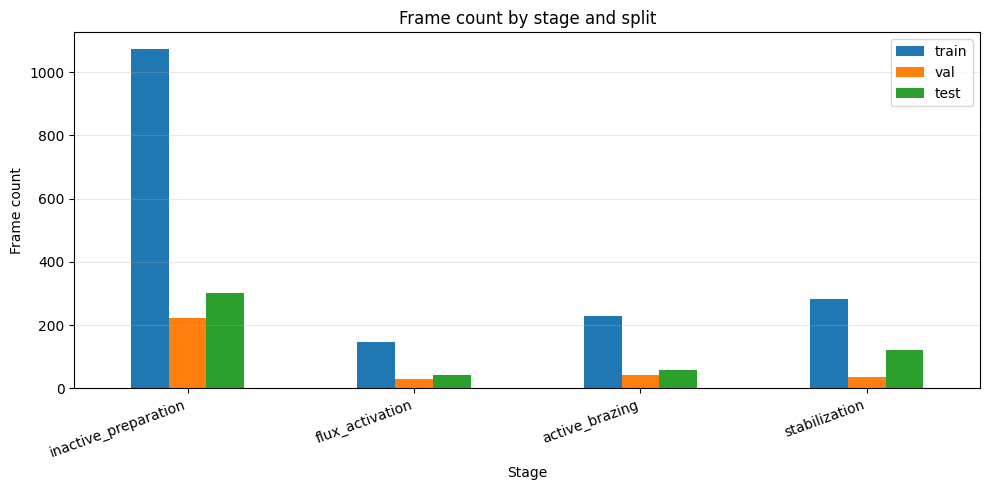

In [29]:
split_counts.plot(kind="bar", figsize=(10, 5))
plt.title("Frame count by stage and split")
plt.xlabel("Stage")
plt.ylabel("Frame count")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### transforms

In [30]:
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomApply([
        transforms.ColorJitter(
            brightness=0.15,
            contrast=0.15,
            saturation=0.10,
            hue=0.03,
        )
    ], p=0.7),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))
    ], p=0.2),
    transforms.RandomRotation(degrees=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

eval_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

### DataLoaders

In [31]:
BATCH_SIZE = 32
NUM_WORKERS = 2

train_dataset = BrazingStageDataset(
    train_df,
    roi=ROI,
    transform=train_transform,
    project_root=ROOT,
)

val_dataset = BrazingStageDataset(
    val_df,
    roi=ROI,
    transform=eval_transform,
    project_root=ROOT,
)

test_dataset = BrazingStageDataset(
    test_df,
    roi=ROI,
    transform=eval_transform,
    project_root=ROOT,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

len(train_dataset), len(val_dataset), len(test_dataset)

(1731, 328, 521)

### visual check

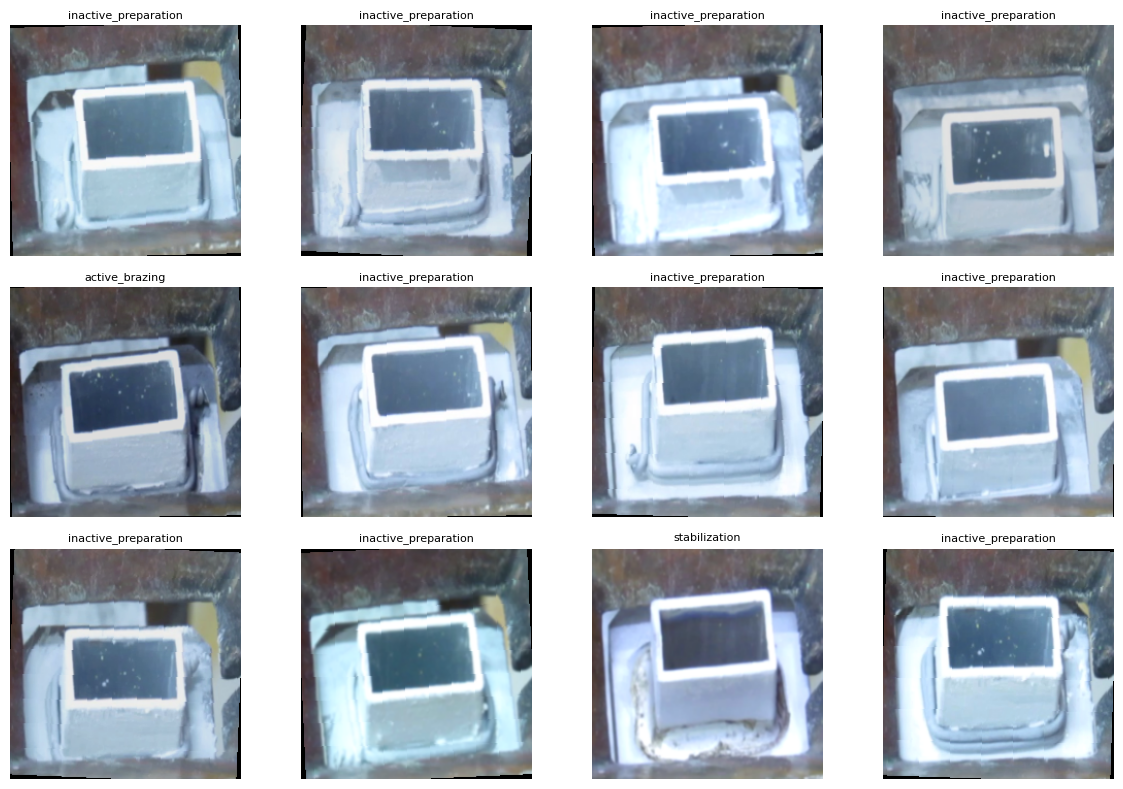

In [32]:
def denormalize_tensor(image_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    image = image_tensor.cpu() * std + mean
    image = image.clamp(0, 1)
    return image.permute(1, 2, 0).numpy()


images, labels, metadata = next(iter(train_loader))

plt.figure(figsize=(12, 8))

for i in range(min(12, len(images))):
    plt.subplot(3, 4, i + 1)
    plt.imshow(denormalize_tensor(images[i]))
    plt.axis("off")
    plt.title(ID_TO_STAGE[int(labels[i])], fontsize=8)

plt.tight_layout()
plt.show()

### class weights

In [33]:
train_counts = train_df["stage_id"].value_counts().sort_index()
train_counts = train_counts.reindex([0, 1, 2, 3]).fillna(0).astype(int)

total = train_counts.sum()
num_classes = len(train_counts)

class_weights = total / (num_classes * train_counts)
class_weights = torch.tensor(class_weights.values, dtype=torch.float32).to(DEVICE)

train_counts, class_weights

(stage_id
 0    1072
 1     148
 2     229
 3     282
 Name: count, dtype: int64,
 tensor([0.4037, 2.9240, 1.8897, 1.5346], device='cuda:0'))

## models

### factory

In [34]:
def create_model(model_name: str, num_classes: int = 4, pretrained: bool = True):
    model_name = model_name.lower()

    if model_name == "resnet18":
        weights = models.ResNet18_Weights.DEFAULT if pretrained else None
        model = models.resnet18(weights=weights)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        return model

    if model_name == "mobilenet_v3_small":
        weights = models.MobileNet_V3_Small_Weights.DEFAULT if pretrained else None
        model = models.mobilenet_v3_small(weights=weights)
        in_features = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_features, num_classes)
        return model

    raise ValueError(f"Unknown model_name: {model_name}")

### train/eval functions

In [35]:
def run_one_epoch(
    model,
    loader,
    criterion,
    optimizer=None,
    device=DEVICE,
):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    all_targets = []
    all_preds = []

    for images, labels, _ in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            logits = model(images)
            loss = criterion(logits, labels)

            if is_train:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * images.size(0)

        preds = torch.argmax(logits, dim=1)

        all_targets.extend(labels.detach().cpu().numpy().tolist())
        all_preds.extend(preds.detach().cpu().numpy().tolist())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    macro_f1 = f1_score(all_targets, all_preds, average="macro")
    weighted_f1 = f1_score(all_targets, all_preds, average="weighted")

    return {
        "loss": avg_loss,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
    }

In [36]:
def train_model(
    model_name: str,
    epochs: int = 25,
    lr: float = 3e-4,
    weight_decay: float = 1e-4,
):
    model = create_model(model_name, num_classes=4, pretrained=True).to(DEVICE)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=4,
    )

    best_val_macro_f1 = -1.0
    best_state = None
    history = []

    for epoch in range(1, epochs + 1):
        start_time = time.time()

        train_metrics = run_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer=optimizer,
            device=DEVICE,
        )

        val_metrics = run_one_epoch(
            model,
            val_loader,
            criterion,
            optimizer=None,
            device=DEVICE,
        )

        scheduler.step(val_metrics["macro_f1"])

        epoch_time = time.time() - start_time

        row = {
            "epoch": epoch,
            "model_name": model_name,
            "lr": optimizer.param_groups[0]["lr"],
            "epoch_time_s": epoch_time,
            **{f"train_{k}": v for k, v in train_metrics.items()},
            **{f"val_{k}": v for k, v in val_metrics.items()},
        }

        history.append(row)

        print(
            f"[{model_name}] "
            f"Epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_metrics['loss']:.4f} "
            f"train_f1={train_metrics['macro_f1']:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} "
            f"val_f1={val_metrics['macro_f1']:.4f} "
            f"val_acc={val_metrics['accuracy']:.4f} | "
            f"{epoch_time:.1f}s"
        )

        if val_metrics["macro_f1"] > best_val_macro_f1:
            best_val_macro_f1 = val_metrics["macro_f1"]
            best_state = {
                "model_name": model_name,
                "model_state_dict": model.state_dict(),
                "epoch": epoch,
                "val_macro_f1": best_val_macro_f1,
                "roi": ROI,
                "image_size": IMAGE_SIZE,
                "stage_order": STAGE_ORDER,
            }

    history_df = pd.DataFrame(history)

    checkpoint_path = CHECKPOINTS_DIR / f"{model_name}_best_{FPS}.pt"
    torch.save(best_state, checkpoint_path)

    history_path = REPORTS_DIR / f"{model_name}_history_{FPS}.csv"
    history_df.to_csv(history_path, index=False)

    print(f"Best val macro-F1 for {model_name}: {best_val_macro_f1:.4f}")
    print(f"Saved checkpoint: {checkpoint_path}")

    model.load_state_dict(best_state["model_state_dict"])

    return model, history_df, checkpoint_path

### ResNet18

In [37]:
resnet18_model, resnet18_history, resnet18_checkpoint = train_model(
    model_name="resnet18",
    epochs=24,
    lr=3e-4,
    weight_decay=1e-4,
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 193MB/s]


[resnet18] Epoch 01/24 | train_loss=0.4531 train_f1=0.7752 | val_loss=0.7496 val_f1=0.5218 val_acc=0.7348 | 17.8s
[resnet18] Epoch 02/24 | train_loss=0.1749 train_f1=0.9042 | val_loss=0.7030 val_f1=0.7813 val_acc=0.8780 | 16.2s
[resnet18] Epoch 03/24 | train_loss=0.1965 train_f1=0.9061 | val_loss=0.1812 val_f1=0.8902 val_acc=0.9482 | 16.3s
[resnet18] Epoch 04/24 | train_loss=0.1912 train_f1=0.9190 | val_loss=0.2483 val_f1=0.7241 val_acc=0.8811 | 16.1s
[resnet18] Epoch 05/24 | train_loss=0.1241 train_f1=0.9447 | val_loss=0.4866 val_f1=0.7517 val_acc=0.8811 | 16.2s
[resnet18] Epoch 06/24 | train_loss=0.1267 train_f1=0.9579 | val_loss=0.4148 val_f1=0.6877 val_acc=0.8110 | 16.2s
[resnet18] Epoch 07/24 | train_loss=0.0636 train_f1=0.9711 | val_loss=0.3693 val_f1=0.7683 val_acc=0.8841 | 16.1s
[resnet18] Epoch 08/24 | train_loss=0.0630 train_f1=0.9700 | val_loss=0.2141 val_f1=0.8512 val_acc=0.9238 | 16.1s
[resnet18] Epoch 09/24 | train_loss=0.0405 train_f1=0.9794 | val_loss=0.3697 val_f1=0.75

### MobileNetV3 Small

In [38]:
mobilenet_model, mobilenet_history, mobilenet_checkpoint = train_model(
    model_name="mobilenet_v3_small",
    epochs=24,
    lr=3e-4,
    weight_decay=1e-4,
)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 119MB/s]


[mobilenet_v3_small] Epoch 01/24 | train_loss=0.6432 train_f1=0.7213 | val_loss=0.4826 val_f1=0.6224 val_acc=0.8201 | 54.5s
[mobilenet_v3_small] Epoch 02/24 | train_loss=0.2307 train_f1=0.8821 | val_loss=0.8443 val_f1=0.5488 val_acc=0.7957 | 16.2s
[mobilenet_v3_small] Epoch 03/24 | train_loss=0.1876 train_f1=0.9053 | val_loss=0.4170 val_f1=0.5978 val_acc=0.8171 | 16.3s
[mobilenet_v3_small] Epoch 04/24 | train_loss=0.1345 train_f1=0.9381 | val_loss=0.3329 val_f1=0.8073 val_acc=0.9055 | 16.2s
[mobilenet_v3_small] Epoch 05/24 | train_loss=0.0827 train_f1=0.9565 | val_loss=0.3523 val_f1=0.7477 val_acc=0.8872 | 16.1s
[mobilenet_v3_small] Epoch 06/24 | train_loss=0.0991 train_f1=0.9589 | val_loss=0.2098 val_f1=0.8579 val_acc=0.9360 | 16.2s
[mobilenet_v3_small] Epoch 07/24 | train_loss=0.1307 train_f1=0.9303 | val_loss=0.3964 val_f1=0.7079 val_acc=0.8445 | 16.1s
[mobilenet_v3_small] Epoch 08/24 | train_loss=0.0784 train_f1=0.9624 | val_loss=0.5879 val_f1=0.7010 val_acc=0.7866 | 16.4s
[mobilen

### results

#### training curves

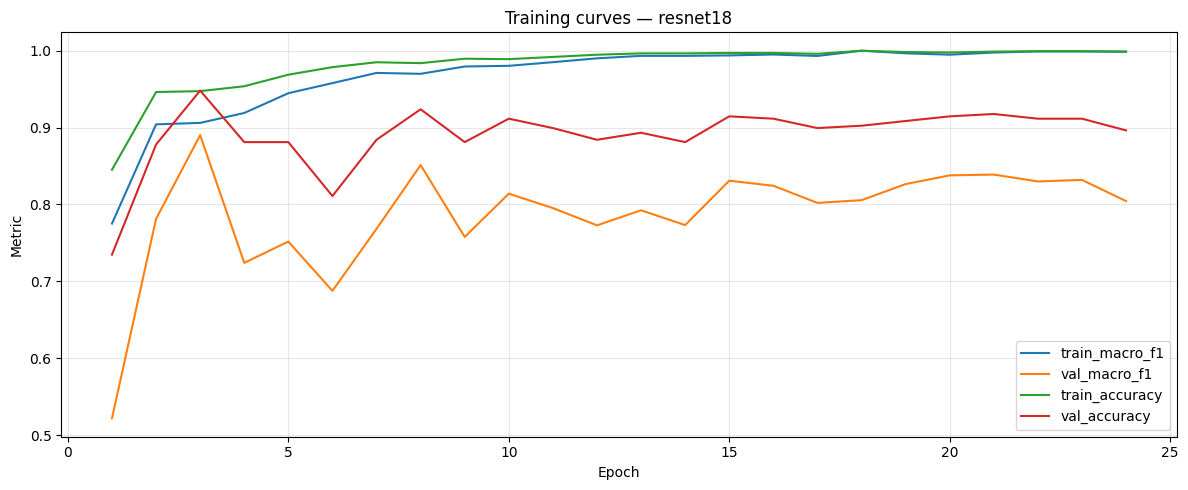

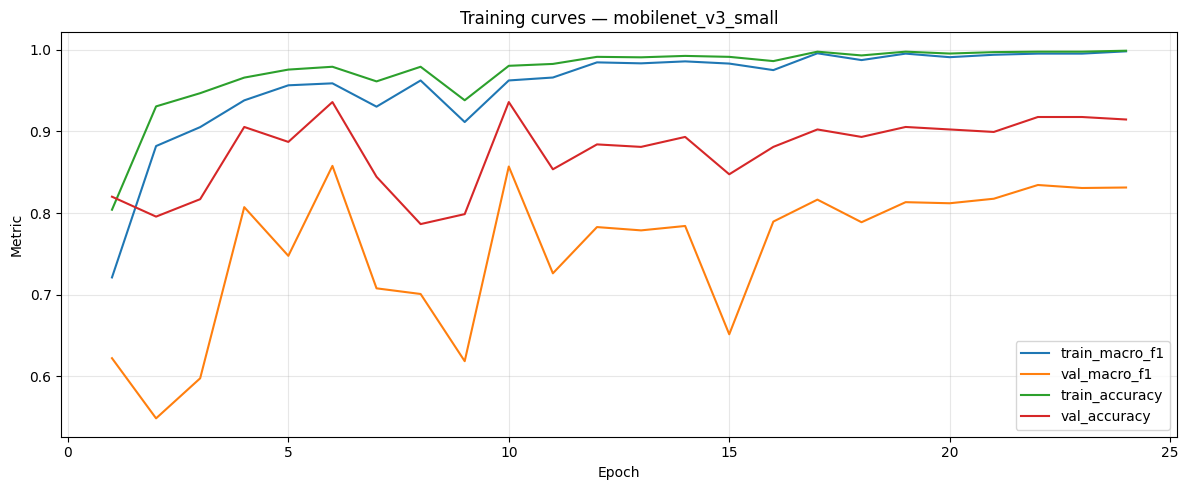

In [39]:
def plot_history(history_df, model_name):
    plt.figure(figsize=(12, 5))

    plt.plot(history_df["epoch"], history_df["train_macro_f1"], label="train_macro_f1")
    plt.plot(history_df["epoch"], history_df["val_macro_f1"], label="val_macro_f1")
    plt.plot(history_df["epoch"], history_df["train_accuracy"], label="train_accuracy")
    plt.plot(history_df["epoch"], history_df["val_accuracy"], label="val_accuracy")

    plt.title(f"Training curves — {model_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Metric")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    output_path = FIGURES_DIR / f"{model_name}_training_curves_{FPS}.png"
    plt.savefig(output_path, dpi=160)
    plt.show()


plot_history(resnet18_history, "resnet18")
plot_history(mobilenet_history, "mobilenet_v3_small")

#### compare validation metrics

In [40]:
model_comparison = pd.DataFrame([
    {
        "model": "resnet18",
        "best_val_macro_f1": resnet18_history["val_macro_f1"].max(),
        "best_val_accuracy": resnet18_history.loc[
            resnet18_history["val_macro_f1"].idxmax(), "val_accuracy"
        ],
        "checkpoint": str(resnet18_checkpoint),
    },
    {
        "model": "mobilenet_v3_small",
        "best_val_macro_f1": mobilenet_history["val_macro_f1"].max(),
        "best_val_accuracy": mobilenet_history.loc[
            mobilenet_history["val_macro_f1"].idxmax(), "val_accuracy"
        ],
        "checkpoint": str(mobilenet_checkpoint),
    },
])

model_comparison

,model,best_val_macro_f1,best_val_accuracy,checkpoint
0,resnet18,0.890165,0.948171,models/checkpoints/neural_baseline_3/resnet18_...
1,mobilenet_v3_small,0.857858,0.935976,models/checkpoints/neural_baseline_3/mobilenet...


#### select best model

In [41]:
best_row = model_comparison.sort_values("best_val_macro_f1", ascending=False).iloc[0]
best_model_name = best_row["model"]
best_checkpoint_path = Path(best_row["checkpoint"])

best_model_name, best_checkpoint_path

('resnet18',
 PosixPath('models/checkpoints/neural_baseline_3/resnet18_best_3.pt'))

In [42]:
checkpoint = torch.load(best_checkpoint_path, map_location=DEVICE)

best_model = create_model(
    checkpoint["model_name"],
    num_classes=4,
    pretrained=False,
).to(DEVICE)

best_model.load_state_dict(checkpoint["model_state_dict"])
best_model.eval()

checkpoint["epoch"], checkpoint["val_macro_f1"]

(3, 0.8901647535834618)

## test

### predict function

In [43]:
def predict_loader(model, loader, device=DEVICE):
    model.eval()

    all_logits = []
    all_probs = []
    all_preds = []
    all_targets = []
    all_metadata = []

    with torch.no_grad():
        for images, labels, metadata in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(images)
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_logits.append(logits.cpu())
            all_probs.append(probs.cpu())
            all_preds.extend(preds.cpu().numpy().tolist())
            all_targets.extend(labels.cpu().numpy().tolist())

            batch_size = len(labels)
            for i in range(batch_size):
                all_metadata.append({
                    "video_id": metadata["video_id"][i],
                    "frame_path": metadata["frame_path"][i],
                    "timestamp_s": float(metadata["timestamp_s"][i]),
                    "stage_name": metadata["stage_name"][i],
                })

    probs_np = torch.cat(all_probs, dim=0).numpy()

    pred_df = pd.DataFrame(all_metadata)
    pred_df["stage_id"] = all_targets
    pred_df["pred_stage_id"] = all_preds
    pred_df["pred_stage_name"] = pred_df["pred_stage_id"].map(ID_TO_STAGE)

    for class_id, stage_name in ID_TO_STAGE.items():
        pred_df[f"prob_{stage_name}"] = probs_np[:, class_id]

    return pred_df

### evaluate function

In [44]:
def evaluate_predictions(pred_df: pd.DataFrame, title: str):
    y_true = pred_df["stage_id"].to_numpy()
    y_pred = pred_df["pred_stage_id"].to_numpy()

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")

    print(title)
    print("-" * 80)
    print(f"accuracy:    {acc:.4f}")
    print(f"macro_f1:    {macro_f1:.4f}")
    print(f"weighted_f1: {weighted_f1:.4f}")
    print()

    print(classification_report(
        y_true,
        y_pred,
        labels=[0, 1, 2, 3],
        target_names=STAGE_ORDER,
        digits=4,
        zero_division=0,
    ))

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2, 3])

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=STAGE_ORDER,
    )

    fig, ax = plt.subplots(figsize=(8, 7))
    disp.plot(ax=ax, xticks_rotation=30, values_format="d")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "confusion_matrix": cm.tolist(),
    }

### test evaluation

Test — resnet18
--------------------------------------------------------------------------------
accuracy:    0.9347
macro_f1:    0.8489
weighted_f1: 0.9307

                      precision    recall  f1-score   support

inactive_preparation     1.0000    0.9834    0.9917       302
     flux_activation     0.6406    1.0000    0.7810        41
      active_brazing     1.0000    0.5000    0.6667        58
       stabilization     0.9160    1.0000    0.9562       120

            accuracy                         0.9347       521
           macro avg     0.8892    0.8709    0.8489       521
        weighted avg     0.9524    0.9347    0.9307       521



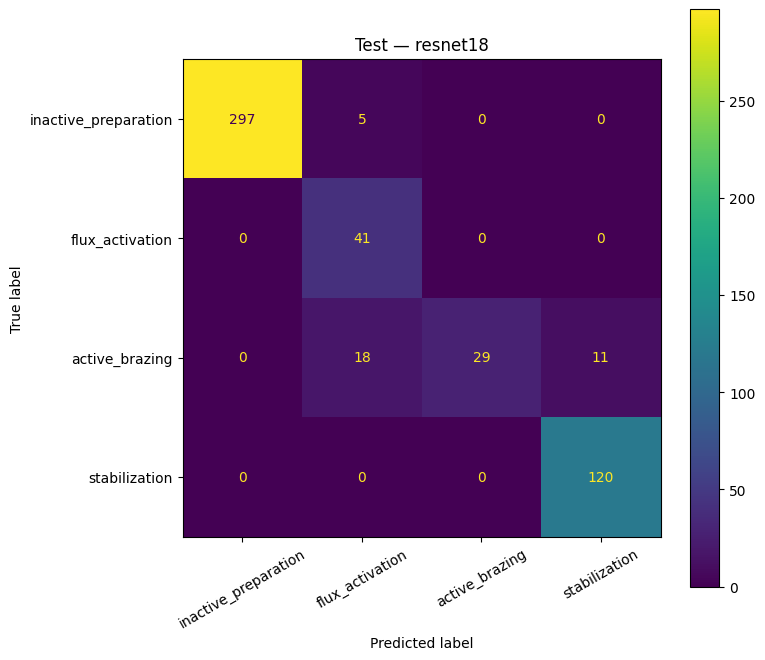

,video_id,frame_path,timestamp_s,stage_name,stage_id,pred_stage_id,pred_stage_name,prob_inactive_preparation,prob_flux_activation,prob_active_brazing,prob_stabilization
0,MVI_6265,data/processed/frames_3/MVI_6265/MVI_6265_0000...,0.000000,inactive_preparation,0,0,inactive_preparation,0.988113,0.007304,0.002729,0.001853
1,MVI_6265,data/processed/frames_3/MVI_6265/MVI_6265_0000...,0.333333,inactive_preparation,0,0,inactive_preparation,0.989617,0.005707,0.003304,0.001372
2,MVI_6265,data/processed/frames_3/MVI_6265/MVI_6265_0000...,0.666667,inactive_preparation,0,0,inactive_preparation,0.976707,0.007849,0.007906,0.007538
3,MVI_6265,data/processed/frames_3/MVI_6265/MVI_6265_0000...,1.000000,inactive_preparation,0,0,inactive_preparation,0.972726,0.013167,0.009795,0.004313
4,MVI_6265,data/processed/frames_3/MVI_6265/MVI_6265_0000...,1.333333,inactive_preparation,0,0,inactive_preparation,0.974369,0.011140,0.009260,0.005231


In [45]:
test_pred_df = predict_loader(best_model, test_loader)

test_metrics = evaluate_predictions(
    test_pred_df,
    title=f"Test — {best_model_name}",
)

test_pred_df.head()

In [46]:
test_pred_df.to_csv(REPORTS_DIR / f"{best_model_name}_test_predictions_{FPS}.csv", index=False)

with open(REPORTS_DIR / f"{best_model_name}_test_metrics_{FPS}.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "model": best_model_name,
            "checkpoint": str(best_checkpoint_path),
            "test_metrics": test_metrics,
            "stage_order": STAGE_ORDER,
            "roi": ROI,
            "image_size": IMAGE_SIZE,
        },
        f,
        ensure_ascii=False,
        indent=2,
    )

### error pairs

In [47]:
errors_df = test_pred_df[test_pred_df["stage_id"] != test_pred_df["pred_stage_id"]].copy()

error_pairs = (
    errors_df
    .groupby(["stage_name", "pred_stage_name"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

error_pairs

,stage_name,pred_stage_name,count
0,active_brazing,flux_activation,18
1,active_brazing,stabilization,11
2,inactive_preparation,flux_activation,5


### timeline plots

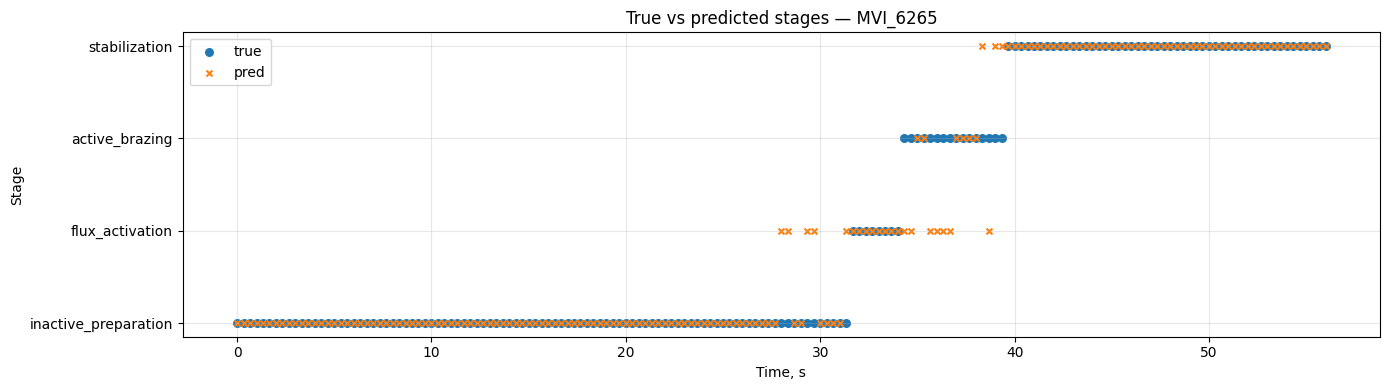

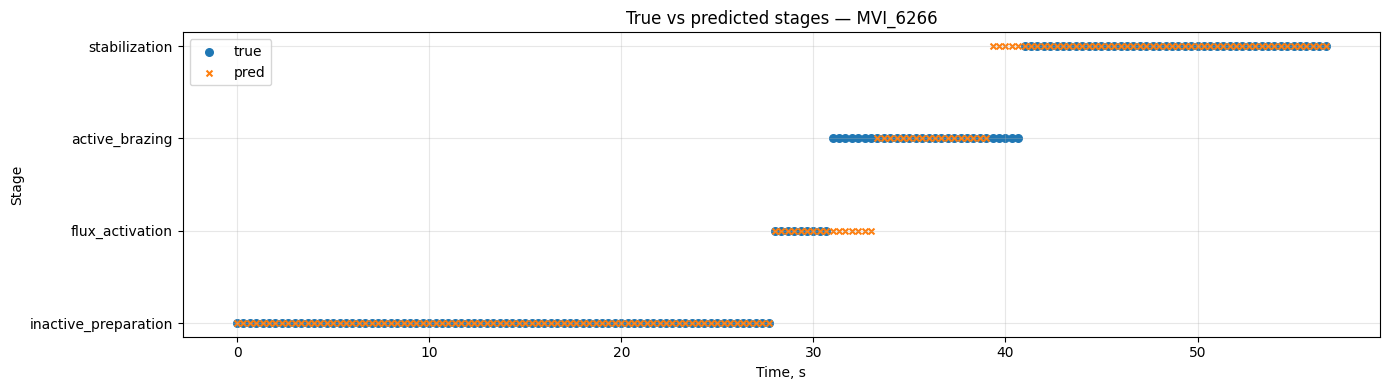

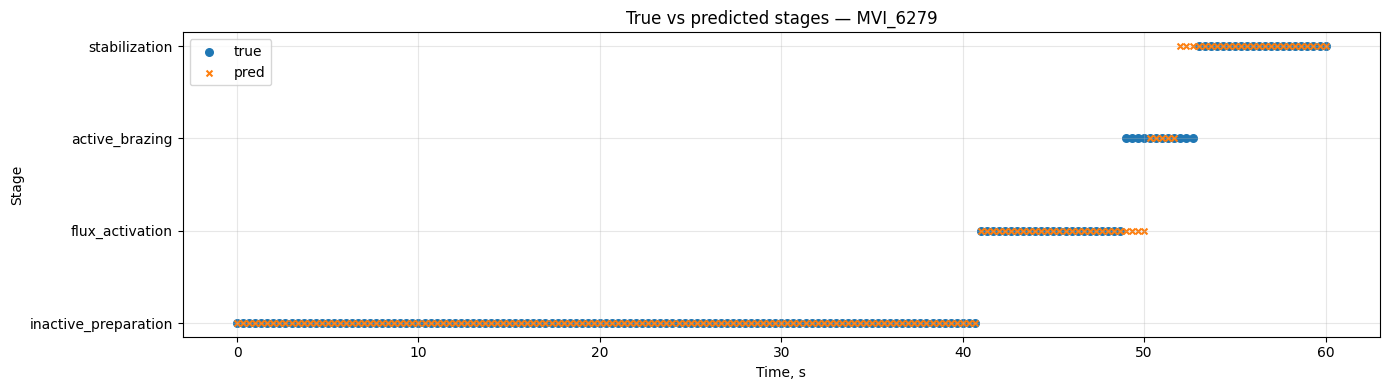

In [48]:
def plot_predictions_for_video(pred_df: pd.DataFrame, video_id: str, output_prefix: str = "raw"):
    video_df = pred_df[pred_df["video_id"] == video_id].sort_values("timestamp_s")

    if len(video_df) == 0:
        print(f"No rows for {video_id}")
        return

    plt.figure(figsize=(14, 4))

    plt.scatter(
        video_df["timestamp_s"],
        video_df["stage_id"],
        s=30,
        label="true",
        marker="o",
    )

    plt.scatter(
        video_df["timestamp_s"],
        video_df["pred_stage_id"],
        s=18,
        label="pred",
        marker="x",
    )

    plt.yticks([0, 1, 2, 3], STAGE_ORDER)
    plt.xlabel("Time, s")
    plt.ylabel("Stage")
    plt.title(f"True vs predicted stages — {video_id}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    output_path = FIGURES_DIR / f"{video_id}_{output_prefix}_neural_predictions_timeline_{FPS}.png"
    plt.savefig(output_path, dpi=160)
    plt.show()


for video_id in sorted(test_pred_df["video_id"].unique()):
    plot_predictions_for_video(test_pred_df, video_id)

## temporal smoothing

In [49]:
def smooth_stage_predictions(
    video_df: pd.DataFrame,
    pred_col: str = "pred_stage_id",
    output_col: str = "pred_stage_id_smooth",
    window_size: int = 5,
) -> pd.DataFrame:
    video_df = video_df.sort_values("timestamp_s").copy()
    preds = video_df[pred_col].to_numpy()

    half = window_size // 2
    smoothed = []

    for i in range(len(preds)):
        left = max(0, i - half)
        right = min(len(preds), i + half + 1)

        window = preds[left:right]
        most_common_stage = Counter(window).most_common(1)[0][0]
        smoothed.append(most_common_stage)

    video_df[output_col] = smoothed
    video_df["pred_stage_name_smooth"] = video_df[output_col].map(ID_TO_STAGE)

    return video_df


smoothed_parts = []

for video_id, video_df in test_pred_df.groupby("video_id"):
    smoothed_parts.append(
        smooth_stage_predictions(
            video_df,
            pred_col="pred_stage_id",
            output_col="pred_stage_id_smooth",
            window_size=5,
        )
    )

test_smoothed_df = pd.concat(smoothed_parts).sort_values(
    ["video_id", "timestamp_s"]
).reset_index(drop=True)

test_smoothed_df.head()

,video_id,frame_path,timestamp_s,stage_name,stage_id,pred_stage_id,pred_stage_name,prob_inactive_preparation,prob_flux_activation,prob_active_brazing,prob_stabilization,pred_stage_id_smooth,pred_stage_name_smooth
0,MVI_6265,data/processed/frames_3/MVI_6265/MVI_6265_0000...,0.000000,inactive_preparation,0,0,inactive_preparation,0.988113,0.007304,0.002729,0.001853,0,inactive_preparation
1,MVI_6265,data/processed/frames_3/MVI_6265/MVI_6265_0000...,0.333333,inactive_preparation,0,0,inactive_preparation,0.989617,0.005707,0.003304,0.001372,0,inactive_preparation
2,MVI_6265,data/processed/frames_3/MVI_6265/MVI_6265_0000...,0.666667,inactive_preparation,0,0,inactive_preparation,0.976707,0.007849,0.007906,0.007538,0,inactive_preparation
3,MVI_6265,data/processed/frames_3/MVI_6265/MVI_6265_0000...,1.000000,inactive_preparation,0,0,inactive_preparation,0.972726,0.013167,0.009795,0.004313,0,inactive_preparation
4,MVI_6265,data/processed/frames_3/MVI_6265/MVI_6265_0000...,1.333333,inactive_preparation,0,0,inactive_preparation,0.974369,0.011140,0.009260,0.005231,0,inactive_preparation


### evaluate smoothing

Test — resnet18 + temporal smoothing
--------------------------------------------------------------------------------
accuracy:    0.9367
macro_f1:    0.8477
weighted_f1: 0.9315

                      precision    recall  f1-score   support

inactive_preparation     1.0000    0.9901    0.9950       302
     flux_activation     0.6508    1.0000    0.7885        41
      active_brazing     1.0000    0.4828    0.6512        58
       stabilization     0.9160    1.0000    0.9562       120

            accuracy                         0.9367       521
           macro avg     0.8917    0.8682    0.8477       521
        weighted avg     0.9532    0.9367    0.9315       521



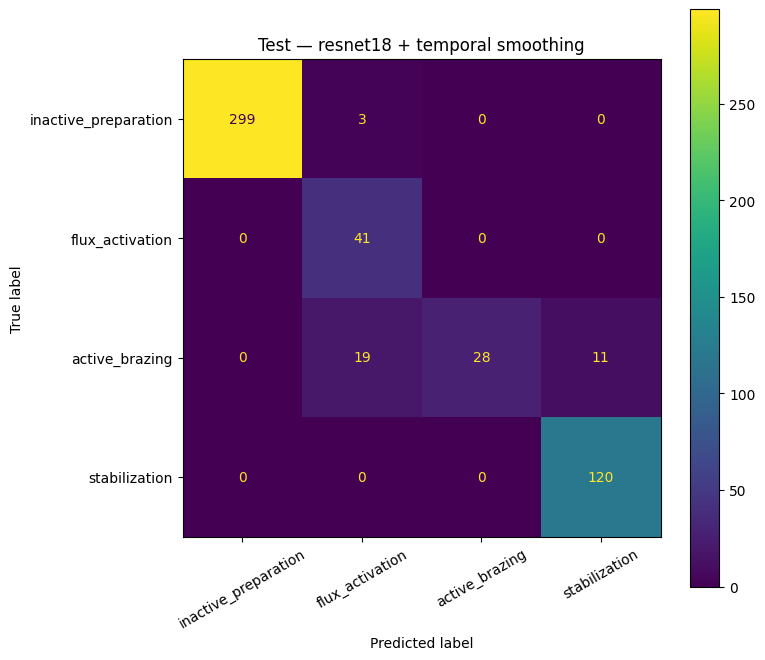

In [50]:
smoothed_eval_df = test_smoothed_df.copy()
smoothed_eval_df["pred_stage_id_raw"] = smoothed_eval_df["pred_stage_id"]
smoothed_eval_df["pred_stage_name_raw"] = smoothed_eval_df["pred_stage_name"]

smoothed_eval_df["pred_stage_id"] = smoothed_eval_df["pred_stage_id_smooth"]
smoothed_eval_df["pred_stage_name"] = smoothed_eval_df["pred_stage_name_smooth"]

smoothed_metrics = evaluate_predictions(
    smoothed_eval_df,
    title=f"Test — {best_model_name} + temporal smoothing",
)

In [51]:
with open(REPORTS_DIR / f"{best_model_name}_test_metrics_smoothed_{FPS}.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "model": best_model_name,
            "checkpoint": str(best_checkpoint_path),
            "window_size": 5,
            "test_metrics": smoothed_metrics,
            "stage_order": STAGE_ORDER,
            "roi": ROI,
            "image_size": IMAGE_SIZE,
        },
        f,
        ensure_ascii=False,
        indent=2,
    )

### timeline plots

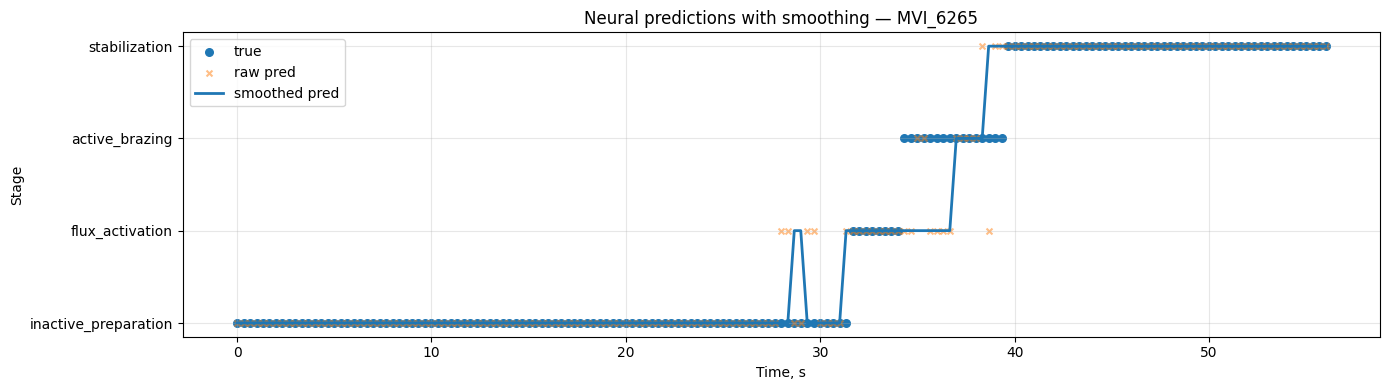

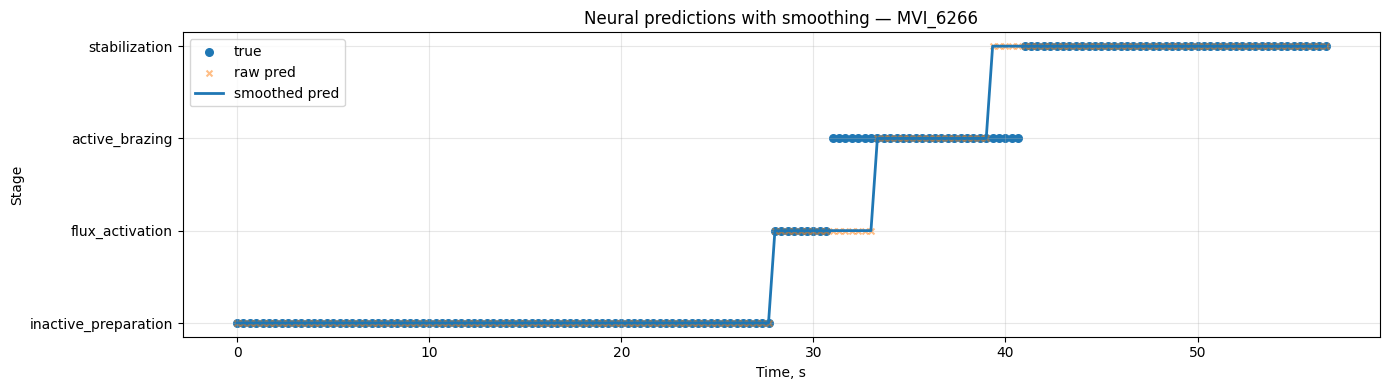

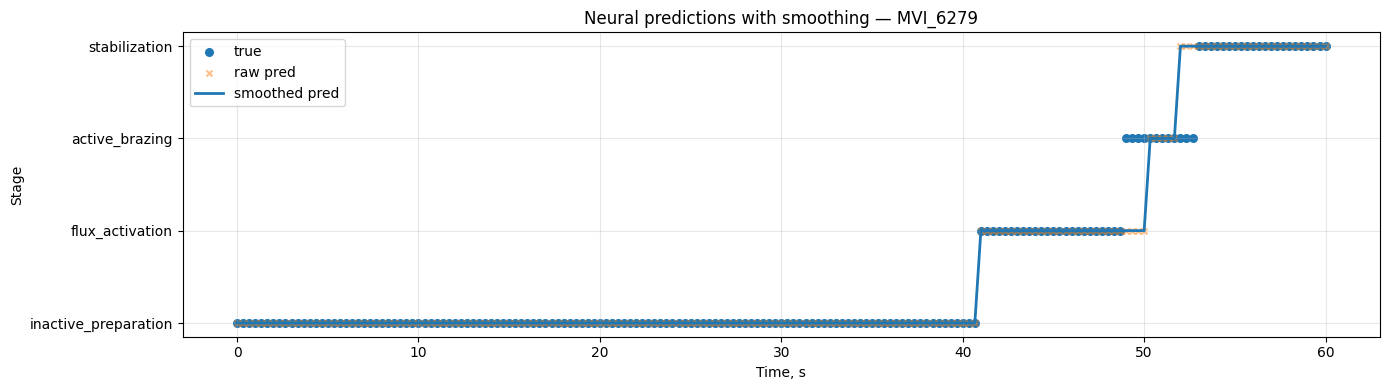

In [52]:
def plot_smoothed_predictions_for_video(video_id: str):
    video_df = test_smoothed_df[
        test_smoothed_df["video_id"] == video_id
    ].sort_values("timestamp_s")

    if len(video_df) == 0:
        print(f"No rows for {video_id}")
        return

    plt.figure(figsize=(14, 4))

    plt.scatter(
        video_df["timestamp_s"],
        video_df["stage_id"],
        s=30,
        label="true",
        marker="o",
    )

    plt.scatter(
        video_df["timestamp_s"],
        video_df["pred_stage_id"],
        s=18,
        label="raw pred",
        marker="x",
        alpha=0.5,
    )

    plt.plot(
        video_df["timestamp_s"],
        video_df["pred_stage_id_smooth"],
        label="smoothed pred",
        linewidth=2,
    )

    plt.yticks([0, 1, 2, 3], STAGE_ORDER)
    plt.xlabel("Time, s")
    plt.ylabel("Stage")
    plt.title(f"Neural predictions with smoothing — {video_id}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    output_path = FIGURES_DIR / f"{video_id}_smoothed_neural_predictions_timeline_{FPS}.png"
    plt.savefig(output_path, dpi=160)
    plt.show()


for video_id in sorted(test_smoothed_df["video_id"].unique()):
    plot_smoothed_predictions_for_video(video_id)

### quick latency check

In [53]:
def benchmark_single_batch(model, batch_size=1, repeats=100, warmup=20):
    model.eval()

    dummy = torch.randn(
        batch_size,
        3,
        IMAGE_SIZE,
        IMAGE_SIZE,
        device=DEVICE,
    )

    with torch.no_grad():
        for _ in range(warmup):
            _ = model(dummy)

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        start = time.time()

        with torch.no_grad():
            for _ in range(repeats):
                _ = model(dummy)

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        elapsed = time.time() - start

    ms_per_batch = elapsed / repeats * 1000
    ms_per_image = ms_per_batch / batch_size

    return {
        "batch_size": batch_size,
        "repeats": repeats,
        "ms_per_batch": ms_per_batch,
        "ms_per_image": ms_per_image,
        "fps_estimate": 1000 / ms_per_image,
    }


latency_results = pd.DataFrame([
    benchmark_single_batch(best_model, batch_size=1),
    benchmark_single_batch(best_model, batch_size=8),
    benchmark_single_batch(best_model, batch_size=16),
])

latency_results

,batch_size,repeats,ms_per_batch,ms_per_image,fps_estimate
0,1,100,2.705705,2.705705,369.589419
1,8,100,2.694302,0.336788,2969.229571
2,16,100,2.683356,0.167710,5962.682977


In [54]:
latency_results.to_csv(REPORTS_DIR / f"{best_model_name}_latency_quick_check_{FPS}.csv", index=False)

# results

In [55]:
!mkdir -p "$DRIVE_CHECKPOINTS_DIR"
!cp -r "$CHECKPOINTS_DIR"/. "$DRIVE_CHECKPOINTS_DIR"/

В рамках нейросетевой ветки был реализован baseline для классификации стадий индукционной пайки по ROI-изображению зоны пайки. Входом модели являлся вырезанный участок кадра, содержащий волновод, область флюса, нижний шов и зоны возможного протекания припоя. Классификация выполнялась по четырём стадиям:

- `inactive_preparation`;
- `flux_activation`;
- `active_brazing`;
- `stabilization`.

В качестве базовых архитектур были проверены `ResNet18` и `MobileNetV3 Small` с предобученными весами ImageNet. Для учёта дисбаланса классов использовалась взвешенная функция потерь `CrossEntropyLoss`.

На validation split лучшей моделью стала `ResNet18`:

```text
ResNet18:
best_val_macro_f1 = 0.8902
best_val_accuracy = 0.9482

MobileNetV3 Small:
best_val_macro_f1 = 0.8579
best_val_accuracy = 0.9360
````

На тестовой выборке `ResNet18` показала следующие результаты:

```text
accuracy:    0.9347
macro_f1:    0.8489
weighted_f1: 0.9307
```

По сравнению с OpenCV baseline после временного сглаживания:

```text
OpenCV baseline + smoothing:
accuracy:    0.6296
macro_f1:    0.5809
weighted_f1: 0.6964
```

нейросетевой подход дал существенный прирост качества:

```text
accuracy:    +0.3051
macro_f1:    +0.2680
weighted_f1: +0.2343
```

Наиболее уверенно модель распознаёт стадии `inactive_preparation` и `stabilization`:

```text
inactive_preparation:
precision = 1.0000
recall    = 0.9834
f1-score  = 0.9917

stabilization:
precision = 0.9160
recall    = 1.0000
f1-score  = 0.9562
```

Стадия `flux_activation` также определяется значительно лучше, чем в OpenCV baseline:

```text
flux_activation:
precision = 0.6406
recall    = 1.0000
f1-score  = 0.7810
```

Это означает, что модель не пропустила ни одного кадра активации флюса на тестовой выборке, однако часть кадров соседних стадий всё ещё ошибочно относится к `flux_activation`.

Основная проблема модели связана со стадией `active_brazing`:

```text
active_brazing:
precision = 1.0000
recall    = 0.5000
f1-score  = 0.6667
```

Модель очень осторожно предсказывает `active_brazing`: если она относит кадр к этой стадии, решение корректно, однако половина настоящих кадров активной пайки ошибочно переходит в соседние классы.

Основные ошибки:

```text
active_brazing → flux_activation: 18
active_brazing → stabilization: 11
inactive_preparation → flux_activation: 5
```

Таким образом, модель хорошо улавливает общую последовательность процесса, но границы активной пайки остаются наиболее сложной частью. Это видно и на временных графиках: для тестовых видео предсказания в целом следуют правильной технологической последовательности, однако участок `active_brazing` местами сужается и частично поглощается стадиями `flux_activation` и `stabilization`.

Простое temporal smoothing почти не изменило качество нейросетевой модели: accuracy немного выросла с 0.9347 до 0.9367, но macro-F1 практически не изменился, а recall стадии active_brazing немного снизился. Поэтому для нейросетевого подхода majority-vote smoothing не является ключевым улучшением; дальнейшая стабилизация должна строиться на технологической логике переходов между стадиями.

Предварительная проверка скорости показала, что прямой инференс модели на используемой GPU-среде занимает около 2.71 мс на изображение при batch size = 1. Этот результат показывает, что выбранная архитектура имеет значительный вычислительный запас относительно ограничения 50 мс/кадр. При этом данный замер не учитывает полный цикл обработки кадра и не характеризует задержку на целевом компьютере оператора. Поэтому ограничение реального времени должно быть дополнительно проверено отдельным end-to-end benchmark, включающим чтение кадра, выделение ROI, изменение размера, нормализацию, инференс модели, временное сглаживание и вывод результата.
```text
batch_size = 1:
ms_per_image ≈ 2.71 ms
fps_estimate ≈ 369.6 FPS
```

Итоговый вывод: нейросетевой baseline на базе `ResNet18` является существенно более эффективным решением задачи определения стадии пайки, чем морфологический OpenCV baseline. Модель уверенно распознаёт подготовительную стадию, активацию флюса и стабилизацию, а также в целом корректно отражает временную структуру процесса. Основным направлением дальнейшего улучшения является повышение полноты распознавания стадии `active_brazing`, поскольку именно она связана с началом плавления и протекания припоя и имеет ключевое значение для будущей управляющей логики.